In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
import re
import scipy.signal as signal
from scipy import sparse
from scipy.sparse.linalg import spsolve
from matplotlib.ticker import MultipleLocator


plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Latin Modern Roman"],  # must be installed on your system
    "mathtext.fontset": "cm",             # Computer Modern math, matches LaTeX style
    "text.usetex": True,                    # render text via LaTeX
    "text.latex.preamble": r"\usepackage{amsmath, amssymb}"
})

# 900 °C

In [2]:
file_path = r"../Data/Raman/900_front_voigt.txt"

data_900 = pd.read_csv(file_path, sep='\t')
print(data_900.info())

<class 'pandas.DataFrame'>
RangeIndex: 934 entries, 0 to 933
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           934 non-null    float64
 1   Raman shift          934 non-null    float64
 2   Intensity            934 non-null    float64
 3   Baseline             934 non-null    float64
 4   Corrected Intensity  934 non-null    float64
 5   Curve 1              934 non-null    float64
 6   Curve 2              934 non-null    float64
 7   Curve 3              934 non-null    float64
 8   Curve 4              934 non-null    float64
 9   Curve 5              934 non-null    float64
 10  Fit Sum              934 non-null    float64
dtypes: float64(11)
memory usage: 80.4 KB
None


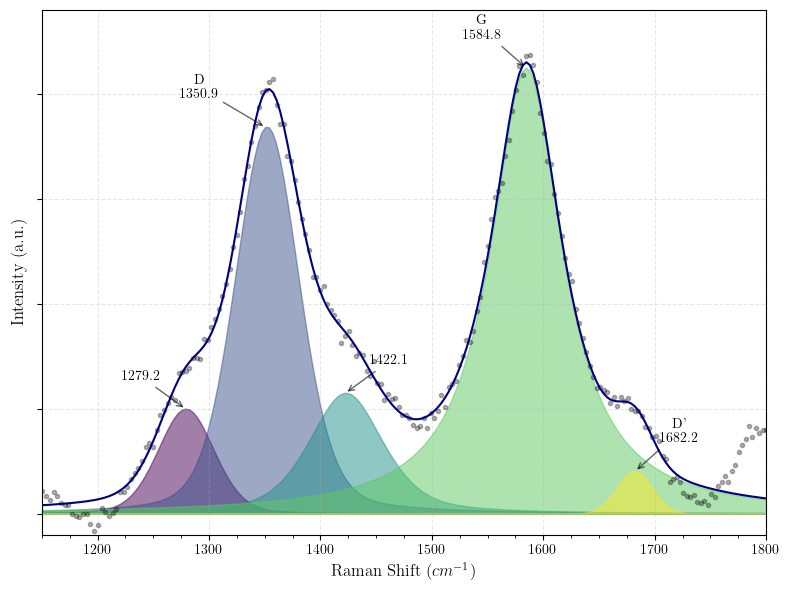

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(data_900['Raman shift'], data_900['Corrected Intensity'], 'k.', alpha=0.3, label='Data')
ax.plot(data_900['Raman shift'], data_900['Fit Sum'], color="#000080", label='Fit Sum')
# fit interval: 1184	1749

peaks = ['Curve 1', 'Curve 2', 'Curve 3', 'Curve 4', 'Curve 5']
colors = plt.get_cmap('viridis')(np.linspace(0, 1, len(peaks)))
for index, peak in enumerate(peaks):
    plt.fill_between(data_900['Raman shift'], data_900[peak], 0, color=colors[index], alpha=0.5, label=peak)

# ----------------------------------------------------------------------------------------------------------------
px1 = data_900['Raman shift'][data_900['Curve 1'].idxmax()]
py1 = data_900['Curve 1'][data_900['Curve 1'].idxmax()]
plt.annotate(f'{px1:.1f}', xy=(px1, py1), 
            xytext=(px1-40, py1 + 250), ha='center', va='bottom', 
            arrowprops=dict(arrowstyle='->', color='black', lw=1, alpha=0.6), fontsize=10, fontweight='bold')

px2 = data_900['Raman shift'][data_900['Curve 2'].idxmax()]
py2 = data_900['Curve 2'][data_900['Curve 2'].idxmax()]
plt.annotate(f'D\n{px2:.1f}', xy=(px2, py2), 
            xytext=(px2-60, py2 + 250), ha='center', va='bottom', 
            arrowprops=dict(arrowstyle='->', color='black', lw=1, alpha=0.6), fontsize=10, fontweight='bold')

px3 = data_900['Raman shift'][data_900['Curve 3'].idxmax()]
py3 = data_900['Curve 3'][data_900['Curve 3'].idxmax()]
plt.annotate(f'{px3:.1f}', xy=(px3, py3), 
            xytext=(px3+40, py3 + 250), ha='center', va='bottom', 
            arrowprops=dict(arrowstyle='->', color='black', lw=1, alpha=0.6), fontsize=10, fontweight='bold')

px4 = data_900['Raman shift'][data_900['Curve 4'].idxmax()]
py4 = data_900['Curve 4'][data_900['Curve 4'].idxmax()]
plt.annotate(f'G\n{px4:.1f}', xy=(px4, py4), 
            xytext=(px4-40, py4 + 250), ha='center', va='bottom', 
            arrowprops=dict(arrowstyle='->', color='black', lw=1, alpha=0.6), fontsize=10, fontweight='bold')

px5 = data_900['Raman shift'][data_900['Curve 5'].idxmax()]
py5 = data_900['Curve 5'][data_900['Curve 5'].idxmax()]
plt.annotate(f"D'\n{px5:.1f}", xy=(px5, py5), 
            xytext=(px5+40, py5 + 250), ha='center', va='bottom', 
            arrowprops=dict(arrowstyle='->', color='black', lw=1, alpha=0.6), fontsize=10, fontweight='bold')
# ----------------------------------------------------------------------------------------------------------------

ax.set_xlabel(r"Raman Shift ($cm^{-1}$)", fontsize=12)
ax.set_ylabel(r"Intensity (a.u.)", fontsize=12)
ax.set_yticklabels([])
ax.set_xlim(1150, 1800)
ax.set_ylim(-200, 4800)
ax.xaxis.set_minor_locator(MultipleLocator(25))
ax.grid(True, linestyle='--', alpha=0.3, zorder=1)
plt.tight_layout()
# plt.savefig(f'../Images/Raman/900_front_fit.pdf', dpi=500)
plt.show()

# 800 °C 

In [3]:
file_path_800 = r"../Data/Raman/800_front_voigt.txt"

data_800 = pd.read_csv(file_path_800, sep='\t')
print(data_800.info())

<class 'pandas.DataFrame'>
RangeIndex: 934 entries, 0 to 933
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           934 non-null    float64
 1   Raman shift          934 non-null    float64
 2   Intensity            934 non-null    float64
 3   Baseline             934 non-null    float64
 4   Corrected Intensity  934 non-null    float64
 5   Curve 1              934 non-null    float64
 6   Curve 2              934 non-null    float64
 7   Curve 3              934 non-null    float64
 8   Curve 4              934 non-null    float64
 9   Curve 5              934 non-null    float64
 10  Fit Sum              934 non-null    float64
dtypes: float64(11)
memory usage: 80.4 KB
None


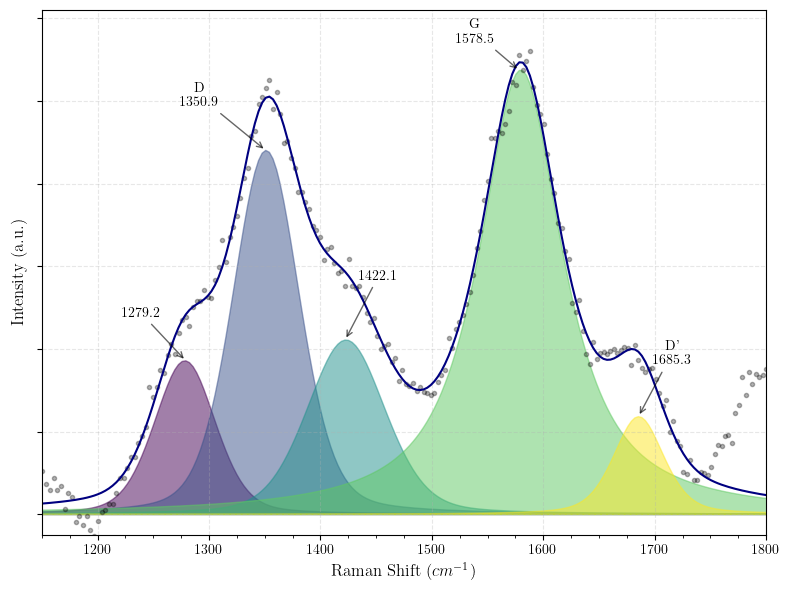

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(data_800['Raman shift'], data_800['Corrected Intensity'], 'k.', alpha=0.3, label='Data')
ax.plot(data_800['Raman shift'], data_800['Fit Sum'], color="#000080", label='Fit Sum')
# fit interval: 1184	1749

peaks = ['Curve 1', 'Curve 2', 'Curve 3', 'Curve 4', 'Curve 5']
colors = plt.get_cmap('viridis')(np.linspace(0, 1, len(peaks)))
for index, peak in enumerate(peaks):
    plt.fill_between(data_800['Raman shift'], data_800[peak], 0, color=colors[index], alpha=0.5, label=peak)

# ----------------------------------------------------------------------------------------------------------------
px1 = data_800['Raman shift'][data_800['Curve 1'].idxmax()]
py1 = data_800['Curve 1'][data_800['Curve 1'].idxmax()]
plt.annotate(f'{px1:.1f}', xy=(px1, py1), 
            xytext=(px1-40, py1 + 250), ha='center', va='bottom', 
            arrowprops=dict(arrowstyle='->', color='black', lw=1, alpha=0.6), fontsize=10, fontweight='bold')

px2 = data_800['Raman shift'][data_800['Curve 2'].idxmax()]
py2 = data_800['Curve 2'][data_800['Curve 2'].idxmax()]
plt.annotate(f'D\n{px2:.1f}', xy=(px2, py2), 
            xytext=(px2-60, py2 + 250), ha='center', va='bottom', 
            arrowprops=dict(arrowstyle='->', color='black', lw=1, alpha=0.6), fontsize=10, fontweight='bold')

px3 = data_800['Raman shift'][data_800['Curve 3'].idxmax()]
py3 = data_800['Curve 3'][data_800['Curve 3'].idxmax()]
plt.annotate(f'{px3:.1f}', xy=(px3, py3), 
            xytext=(px3+30, py3 + 350), ha='center', va='bottom', 
            arrowprops=dict(arrowstyle='->', color='black', lw=1, alpha=0.6), fontsize=10, fontweight='bold')

px4 = data_800['Raman shift'][data_800['Curve 4'].idxmax()]
py4 = data_800['Curve 4'][data_800['Curve 4'].idxmax()]
plt.annotate(f'G\n{px4:.1f}', xy=(px4, py4), 
            xytext=(px4-40, py4 + 150), ha='center', va='bottom', 
            arrowprops=dict(arrowstyle='->', color='black', lw=1, alpha=0.6), fontsize=10, fontweight='bold')

px5 = data_800['Raman shift'][data_800['Curve 5'].idxmax()]
py5 = data_800['Curve 5'][data_800['Curve 5'].idxmax()]
plt.annotate(f"D'\n{px5:.1f}", xy=(px5, py5), 
            xytext=(px5+30, py5 + 300), ha='center', va='bottom', 
            arrowprops=dict(arrowstyle='->', color='black', lw=1, alpha=0.6), fontsize=10, fontweight='bold')
# ----------------------------------------------------------------------------------------------------------------

ax.set_xlabel(r"Raman Shift ($cm^{-1}$)", fontsize=12)
ax.set_ylabel(r"Intensity (a.u.)", fontsize=12)
ax.set_yticklabels([])
ax.set_xlim(1150, 1800)
ax.set_ylim(-125, 3050)
ax.xaxis.set_minor_locator(MultipleLocator(25))
ax.grid(True, linestyle='--', alpha=0.3, zorder=1)
plt.tight_layout()
# plt.savefig(f'../Images/Raman/800_front_fit.pdf', dpi=500)
plt.show()

# Combined plot carbon

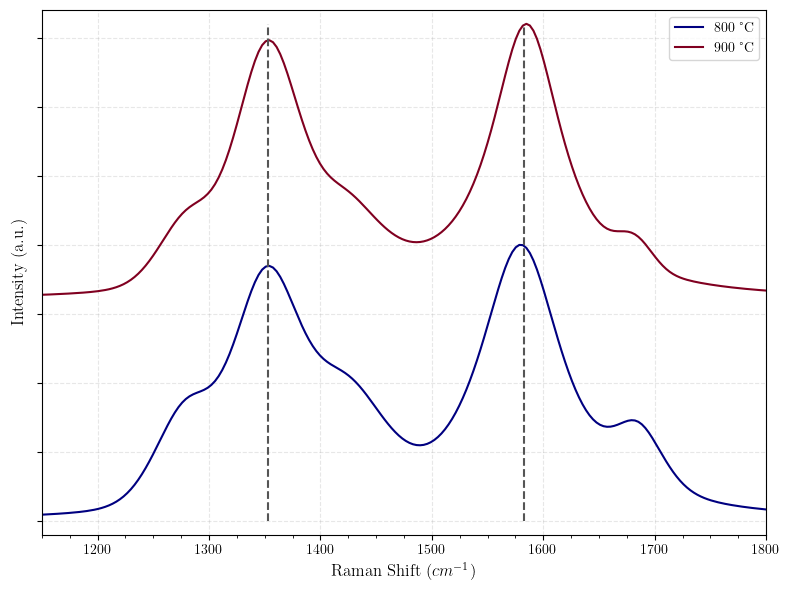

In [24]:
fig, ax = plt.subplots(figsize=(8, 6))

norm_800 = data_800['Fit Sum'] / data_800['Fit Sum'].max()
norm_900 = data_900['Fit Sum'] / data_900['Fit Sum'].max()
# norm_800 = data_800['Corrected Intensity'] / data_800['Corrected Intensity'].max()
# norm_900 = data_900['Corrected Intensity'] / data_900['Corrected Intensity'].max()

ax.plot(data_800['Raman shift'], norm_800, color="#000080", label='800 °C')
ax.plot(data_900['Raman shift'], norm_900 + 0.8, color="#800020", label='900 °C')

ax.vlines([1352.5, 1583], ymin=0, ymax=1.8, color="#555555", linestyle='--')

ax.set_xlabel(r"Raman Shift ($cm^{-1}$)", fontsize=12)
ax.set_ylabel(r"Intensity (a.u.)", fontsize=12)
ax.set_yticklabels([])
ax.set_xlim(1150, 1800)
ax.set_ylim(-0.05, 1.85)
ax.xaxis.set_minor_locator(MultipleLocator(25))
ax.grid(True, linestyle='--', alpha=0.3, zorder=1)
plt.legend()
plt.tight_layout()
# plt.savefig(f'../Images/Raman/800_front_fit.pdf', dpi=500)
plt.show()

# Combined plot nickel silicides

96.3546 $Ni_2Si$
137.8 $Ni_2Si$
181 $Ni_2Si$
212 $Ni_2Si$
363 $NiSi$


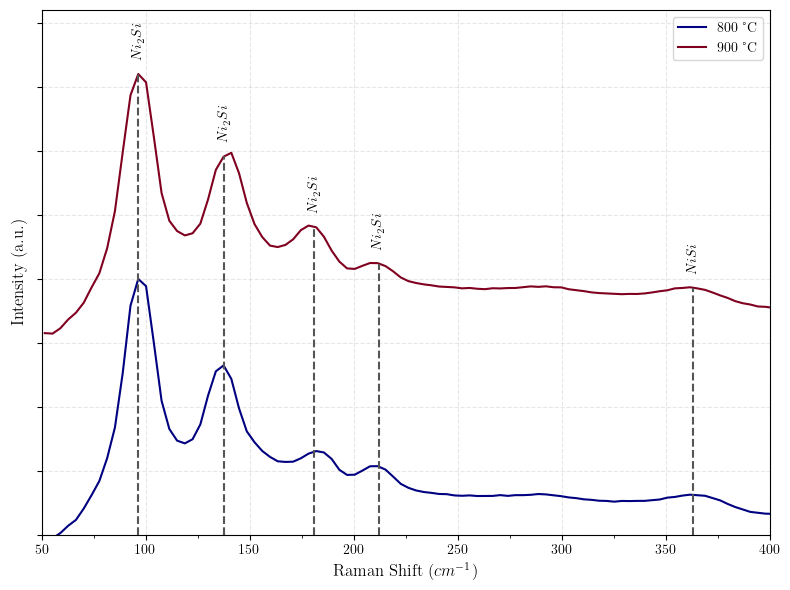

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

data_800["norm_800"] = data_800['Corrected Intensity'] / data_800['Corrected Intensity'].max()
data_900["norm_900"] = data_900['Corrected Intensity'] / data_900['Corrected Intensity'].max()

offset = 0.8
ax.plot(data_800['Raman shift'], data_800["norm_800"], color="#000080", label='800 °C')
ax.plot(data_900['Raman shift'], data_900["norm_900"] + offset, color="#800020", label='900 °C')

# ax.vlines([1352.5, 1583], ymin=0, ymax=1.8, color="#555555", linestyle='--')
peak_labels = {96.3546: '$Ni_2Si$', 137.8: '$Ni_2Si$', 181: '$Ni_2Si$', 212: '$Ni_2Si$', 363: '$NiSi$'}

for position, name in peak_labels.items():
    print(position, name)
    y_height = np.interp(position, data_900['Raman shift'], data_900['norm_900'])
    ax.vlines([position], ymin=0, ymax=y_height + offset, color="#555555", linestyle='--')
    plt.text(position, y_height +offset+ 0.05, name, 
            ha='center', va='bottom', fontsize=10, fontweight='bold', rotation=90)
    

ax.set_xlabel(r"Raman Shift ($cm^{-1}$)", fontsize=12)
ax.set_ylabel(r"Intensity (a.u.)", fontsize=12)
ax.set_yticklabels([])
ax.set_xlim(50, 400)
ax.set_ylim(0, 2.05)
ax.xaxis.set_minor_locator(MultipleLocator(25))
ax.grid(True, linestyle='--', alpha=0.3, zorder=1)
plt.legend()
plt.tight_layout()
# plt.savefig(f'../Images/Raman/NiSi.pdf', dpi=500)
plt.show()

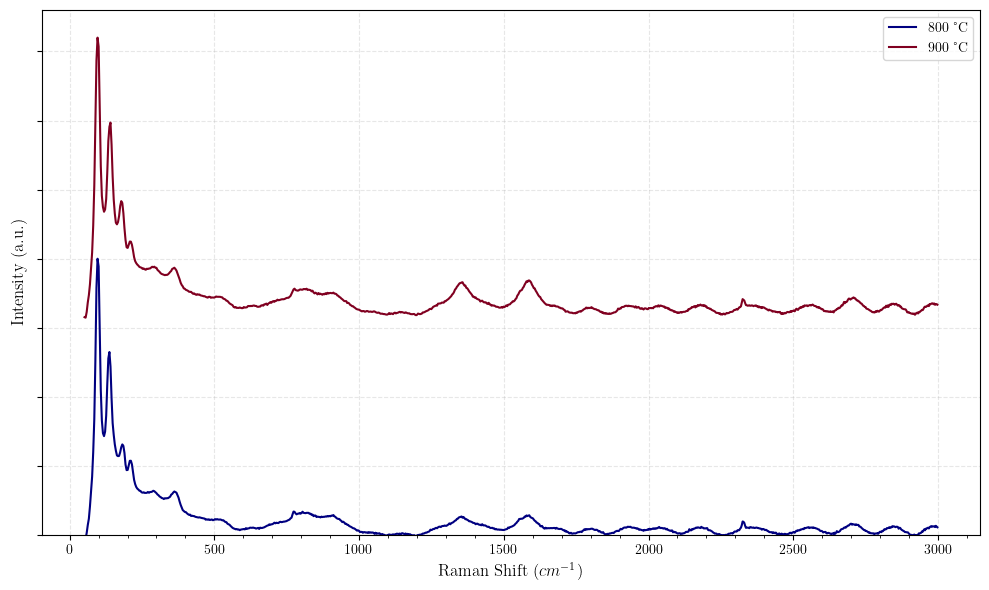

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))

data_800["norm_800"] = data_800['Corrected Intensity'] / data_800['Corrected Intensity'].max()
data_900["norm_900"] = data_900['Corrected Intensity'] / data_900['Corrected Intensity'].max()

offset = 0.8
ax.plot(data_800['Raman shift'], data_800["norm_800"], color="#000080", label='800 °C')
ax.plot(data_900['Raman shift'], data_900["norm_900"] + offset, color="#800020", label='900 °C')

ax.set_xlabel(r"Raman Shift ($cm^{-1}$)", fontsize=12)
ax.set_ylabel(r"Intensity (a.u.)", fontsize=12)
ax.set_yticklabels([])
# ax.set_xlim(50, 400)
ax.set_ylim(0, 1.9)
ax.xaxis.set_minor_locator(MultipleLocator(100))
ax.grid(True, linestyle='--', alpha=0.3, zorder=1)
plt.legend()
plt.tight_layout()
# plt.savefig(f'../Images/Raman/NiSi.pdf', dpi=500)
plt.show()